# Synthèse radiale multi-scénarios

Roue radiale des limites planétaires (LP) : 1 secteur par LP, 1 barre radiale
par scénario (hauteur = valeur / Lower Bound, donc la Lower Bound est un
cercle de rayon constant = 1L), bande extérieure annotée (valeur absolue pour
le scénario de référence, variation % pour les autres) et arc Upper Bound
propre à chaque secteur (le ratio Upper/Lower Bound varie selon le LP).
Aucun dégradé de couleur entre scénarios : seule la position angulaire (et le
texte de la bande extérieure) les distingue au sein d'un secteur.

Réutilise les mêmes données que `Synthèse multi-scénarios.ipynb`
(`create_synthesis_figure_by_lp`), représentées sous une forme radiale plutôt
qu'en grille de subplots.

Génère 2 figures dans `figures/` :
- `radial_synthesis_cba_all_scenarios.png` : barres empilées domestique
  (plein) + importé (hachuré) par catégorie de consommation, comme
  `create_stacked_bar_chart` (activable/désactivable via `show_categories` /
  `show_import_split`).
- `radial_synthesis_pba_all_scenarios.png` : barre pleine, colorée par le LP --
  le PBA est un scalaire unique dans les données sources, sans ventilation par
  catégorie ni domestique/importé possible.

Logique de calcul et de tracé partagée avec les autres notebooks via le
package [`planefr_lib`](./planefr_lib/).

In [1]:
import sys
if r"C:\Users\Arnaud\Documents\PlaneFR\notebooks" not in sys.path:
    sys.path.insert(0, r"C:\Users\Arnaud\Documents\PlaneFR\notebooks")

import matplotlib.pyplot as plt

from planefr_lib import config, io, processing
from planefr_lib.plot_radial_synthesis import create_radial_synthesis_figure

## 1. Chargement des données et traitement des scénarios

In [2]:
facteurs_carac_df = io.load_facteurs_carac()
bridge_matrices_df = io.load_bridge_matrices()
seuils_df = io.load_seuils()
dls_df = io.load_dls()

scenario_folders = config.get_scenario_folders(exclude_2019=True)
scenario_names = [f.name for f in scenario_folders]
print(f"Scénarios trouvés ({len(scenario_folders)}): {scenario_names}")

all_scenarios_data = []
for scenario_folder in scenario_folders:
    print(f"Traitement : {scenario_folder.name}")
    data_by_subprocess, _ = processing.process_scenario(
        scenario_folder, facteurs_carac_df, bridge_matrices_df, seuils_df
    )
    all_scenarios_data.append(data_by_subprocess)

assert len(all_scenarios_data) == len(scenario_folders), "Certains scénarios n'ont produit aucune donnée"
print(f"\n{len(all_scenarios_data)}/{len(scenario_folders)} scénarios traités avec succès.")

Scénarios trouvés (4): ['Base_year_2015', 'Sufficiency_NZE_2050', 'Tech_NZE_2050', 'TREND_2050']
Traitement : Base_year_2015
Traitement : Sufficiency_NZE_2050
Traitement : Tech_NZE_2050
Traitement : TREND_2050

4/4 scénarios traités avec succès.


## 2. Roue radiale — comptabilité consommation (CBA)

Barres empilées : domestique (plein) + importé (hachuré), par catégorie de
consommation. Mettre `show_categories=False` et/ou `show_import_split=False`
pour simplifier l'habillage (la barre revient alors à une couleur pleine,
celle du LP, comme la figure PBA ci-dessous).

`radial_power=1/3` dilate l'échelle radiale plus fortement qu'une racine
carrée : les LP en-deçà de leur Lower Bound (ex. Blue water consumption)
restent visibles, sans que les LP en fort dépassement (ex. GHG emissions)
n'écrasent le reste de la figure. Remonter vers 1.0 pour une échelle linéaire
stricte.

Sauvegardé : radial_synthesis_cba_all_scenarios.png


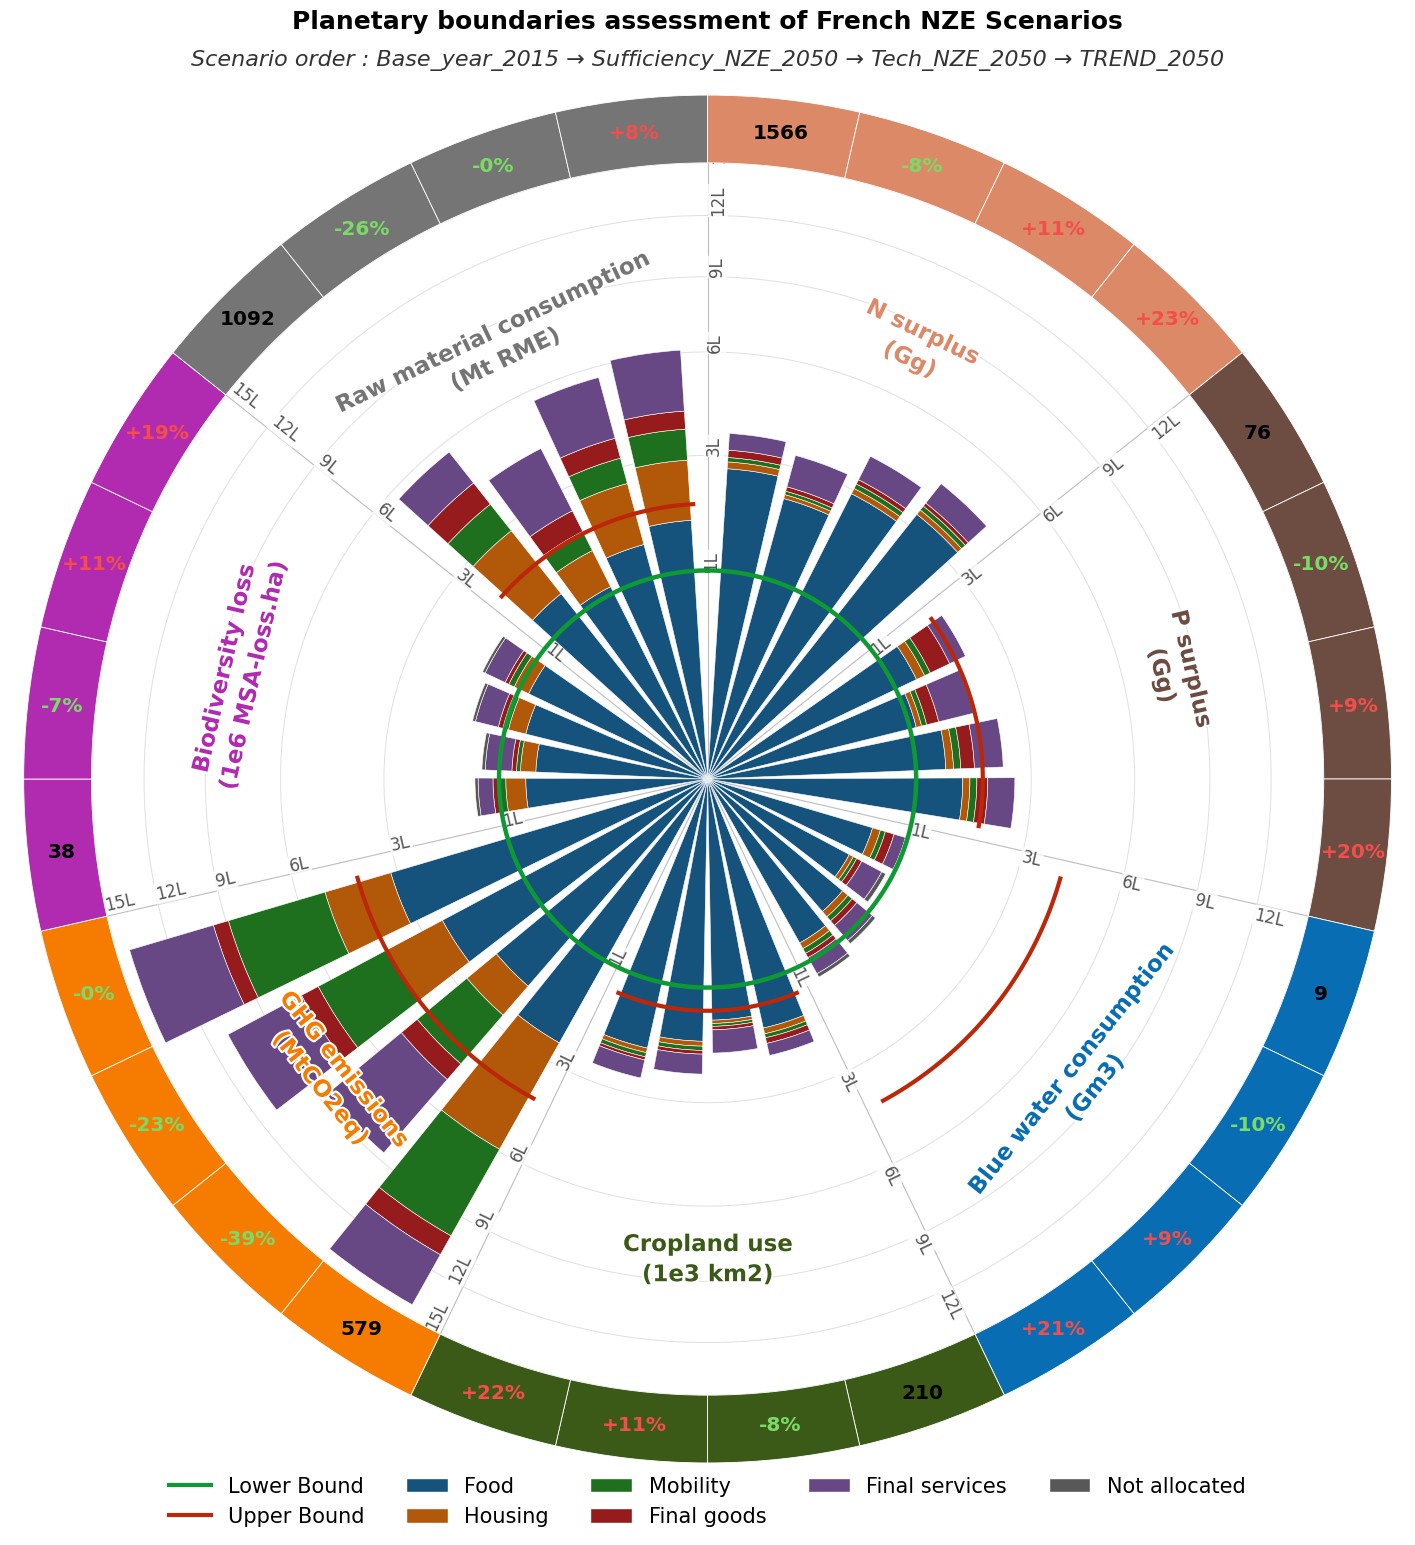

In [3]:
fig_cba, _ = create_radial_synthesis_figure(
    all_scenarios_data, seuils_df, scenario_names,
    show_cba=True, show_pba=False,
    dls_df=dls_df, show_dls=False,
    radial_power=0.4,
    show_categories=True, show_import_split=False,
    title="Planetary boundaries assessment of French NZE Scenarios",
)

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
output_path = config.FIGURES_DIR / "radial_synthesis_cba_all_scenarios.png"
fig_cba.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Sauvegardé : {output_path.name}")
plt.show()

## 3. Roue radiale — comptabilité production (PBA)

Le PBA est un scalaire unique dans les données sources (pas de ventilation
par catégorie ni domestique/importé) : la barre est donc toujours pleine,
colorée par le LP.

Sauvegardé : radial_synthesis_pba_all_scenarios.png


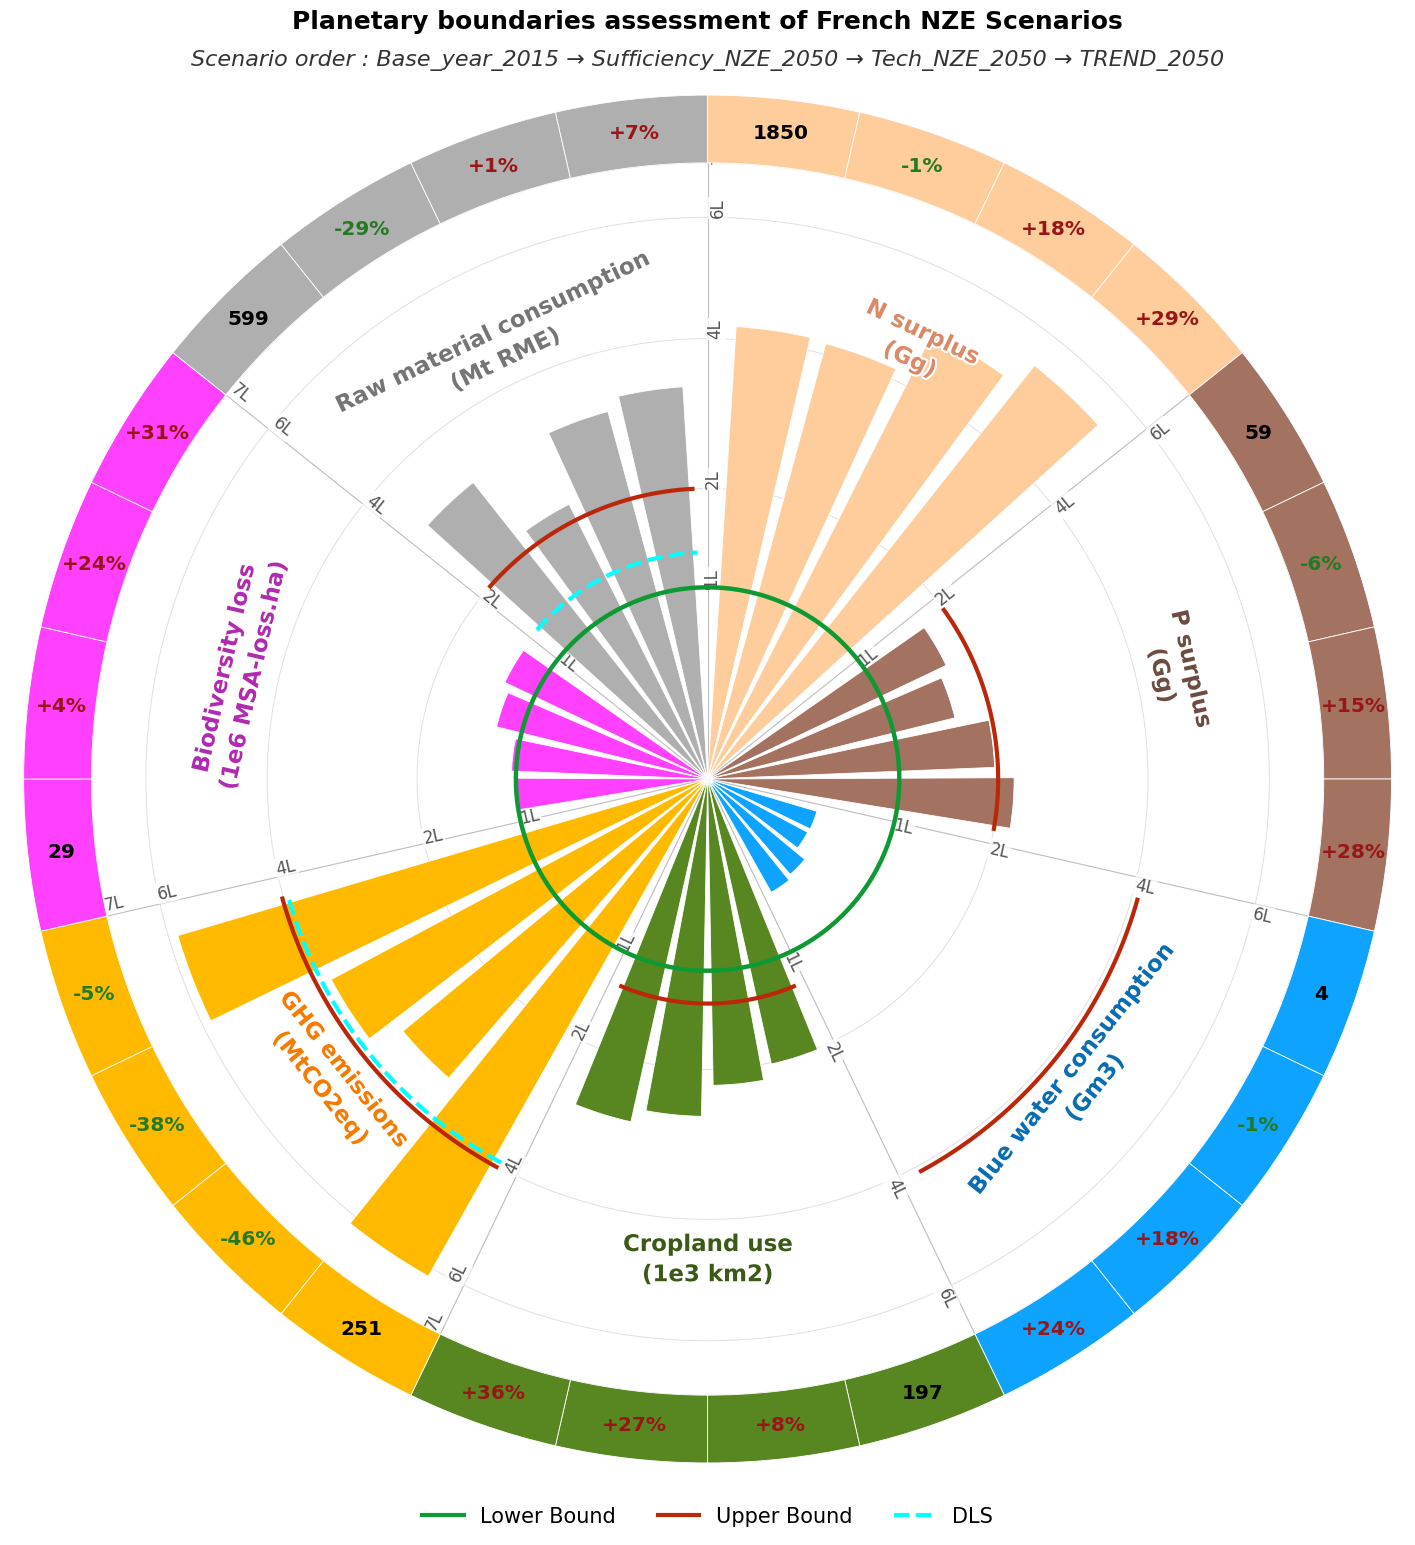

In [4]:
fig_pba, _ = create_radial_synthesis_figure(
    all_scenarios_data, seuils_df, scenario_names,
    show_cba=False, show_pba=True,
    dls_df=dls_df, show_dls=True,
    radial_power=0.6,
    title="Planetary boundaries assessment of French NZE Scenarios",
)

output_path = config.FIGURES_DIR / "radial_synthesis_pba_all_scenarios.png"
fig_pba.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Sauvegardé : {output_path.name}")
plt.show()

## 4. Roue radiale — CBA et PBA combinés

Les deux comptabilités sur la même figure (`show_cba=True, show_pba=True`,
le réglage par défaut) : pour chaque scénario, 2 barres adjacentes dans
chaque secteur -- CBA (couleur pleine du LP) puis PBA (nuance plus claire de
la même couleur). La bande extérieure suit le même découpage (2 sous-bandes
par scénario). Titre, légende et sous-titre s'adaptent automatiquement.
`show_categories=False, show_import_split=False` ici pour garder le CBA plein
comme le PBA (comparaison directe, non encombrée par le détail des
catégories) -- passer `show_categories=True` pour retrouver le détail
domestique/importé par catégorie côté CBA.

Sauvegardé : radial_synthesis_both_all_scenarios.png


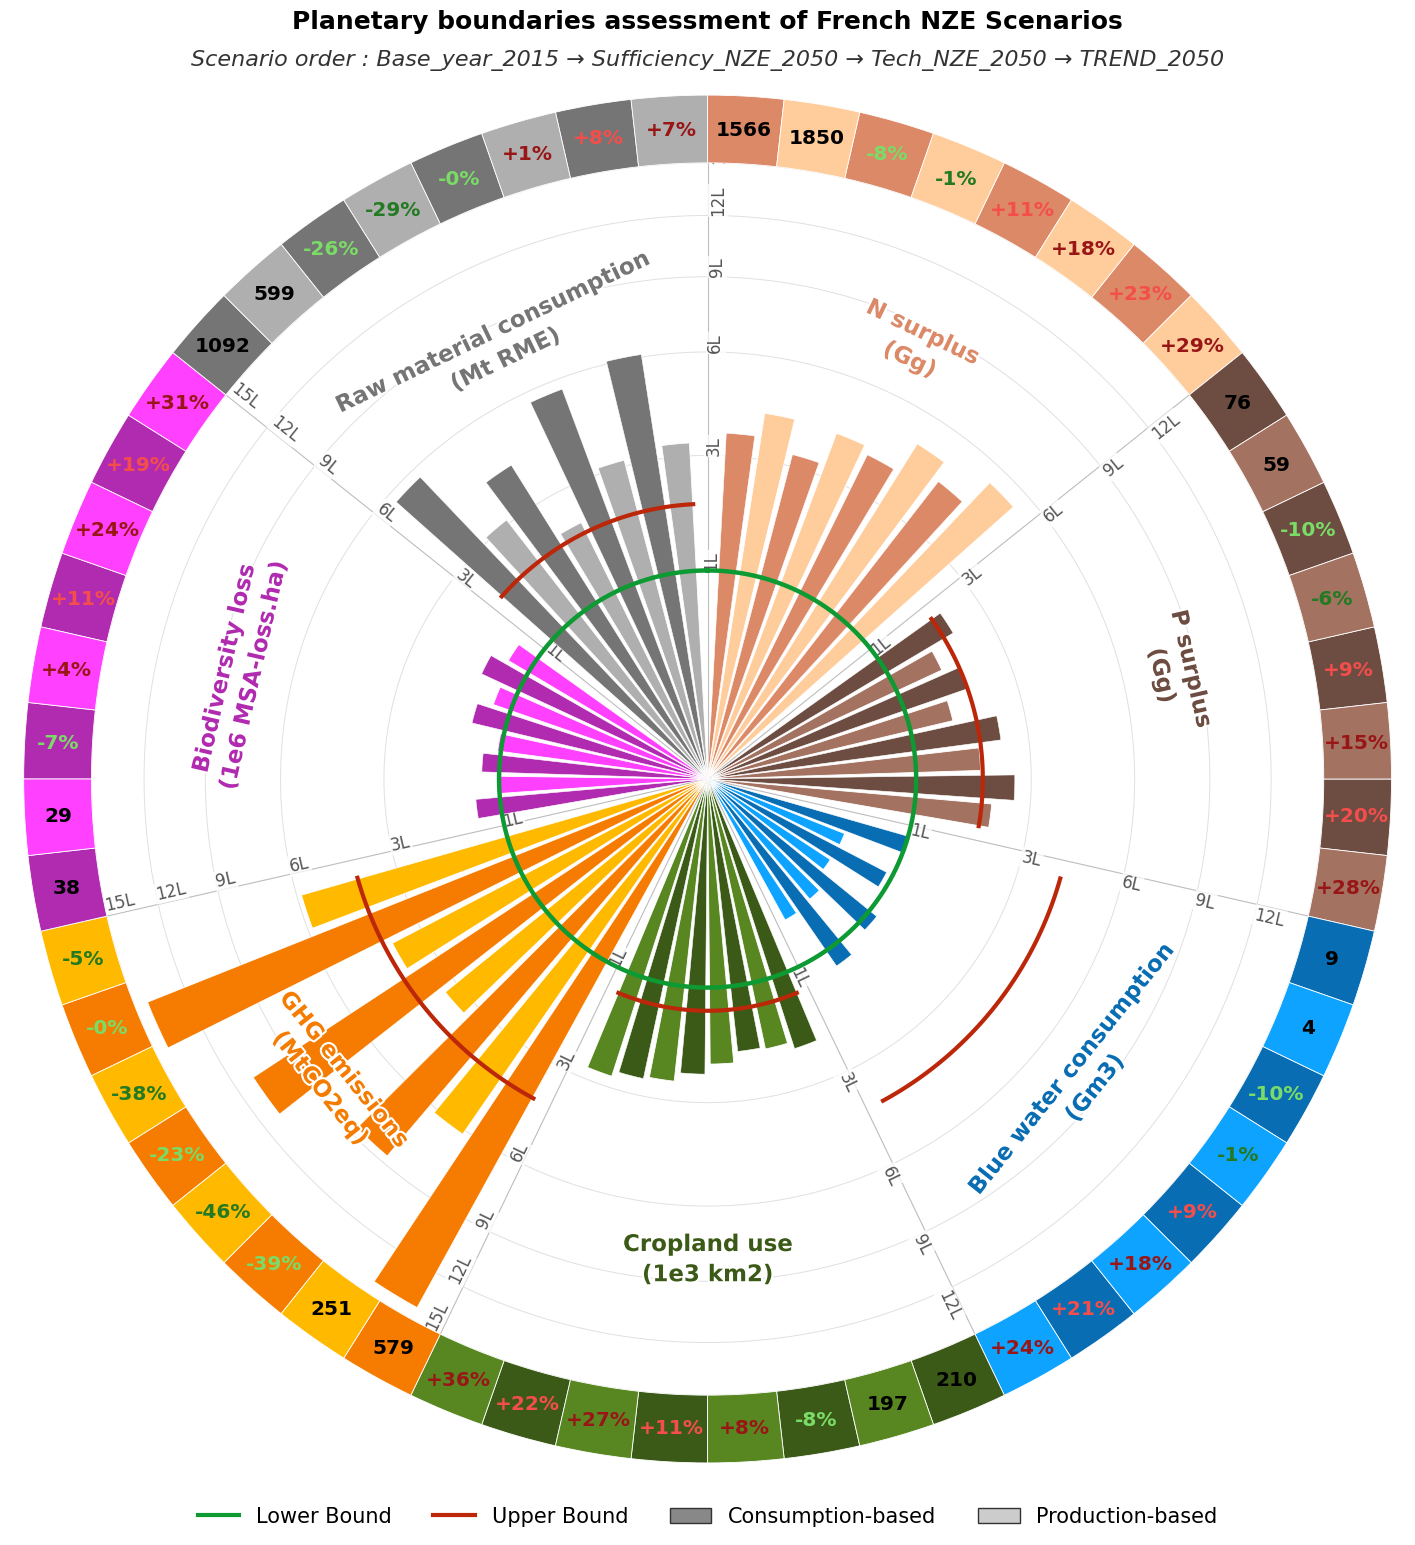

In [5]:
fig_both, _ = create_radial_synthesis_figure(
    all_scenarios_data, seuils_df, scenario_names,
    show_cba=True, show_pba=True,
    dls_df=dls_df, show_dls=False,
    radial_power=0.4,
    show_categories=False, show_import_split=False,
    title="Planetary boundaries assessment of French NZE Scenarios",
)

output_path = config.FIGURES_DIR / "radial_synthesis_both_all_scenarios.png"
fig_both.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Sauvegardé : {output_path.name}")
plt.show()